In [1]:
import os
import numpy as np
import mne
from scipy.stats import sem
import matplotlib.pyplot as plt

In [ ]:
# ---------------------------------------------------------------------
# USER SETTINGS --------------------------------------------------------
# ---------------------------------------------------------------------
BASE_DIR  = r"C:\Users\cdd\Documents\Uni\Special_course\ds003838-download"
OUT_DIR = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\EEG_amica_processed"
SUBJECTS = [32]
# SUBJECTS   = np.setdiff1d(np.arange(32, 99), [37, 53, 66, 94, 96])
#SUBJECTS   = np.setdiff1d(np.arange(32, 60), [37])
RESAMPLE  = 250                       # Hz; speeds up the TFR ∼4×

In [3]:
for subj in SUBJECTS:
    raw_path = os.path.join(BASE_DIR,
                            f"sub-{subj:03d}", "eeg",
                            f"sub-{subj:03d}_task-memory_eeg.set")
    if not os.path.exists(raw_path):
        continue  # subject missing

    print(f"▶  Subject {subj:03d}")
    raw = mne.io.read_raw_eeglab(raw_path, preload=True, verbose='error')

▶  Subject 032


c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\pymatreader\utils.py:168: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(


In [4]:

    raw.filter(1., 45., fir_design='firwin', verbose='error')
    raw.set_eeg_reference('average', verbose='error')
    raw.resample(RESAMPLE, verbose='error')

<RawEEGLAB | sub-032_task-memory_eeg.set, 63 x 1848830 (7395.3 s), ~888.7 MB, data loaded>

In [5]:
# Show all unique annotation labels
print("Unique annotation labels:", set(raw.annotations.description))

# Extract just those whose label starts with "bad" (case-insensitive)
bad_annot = [
    (onset, duration, desc)
    for onset, duration, desc in zip(raw.annotations.onset,
                                     raw.annotations.duration,
                                     raw.annotations.description)
    if desc.lower().startswith("bad")
]

print(f"\nFound {len(bad_annot)} ‘bad’ segments:")
for onset, dur, desc in bad_annot[:10]:          # show first few
    print(f"  {desc:20s}  onset={onset:8.1f}s  duration={dur:4.1f}s")


Unique annotation labels: {'6002091', '6005130', '6003090', '500209', '500405', '500809', '6003051', '500109', '6012130', '6008131', '6009090', '6001131', '6008090', '6009091', '500513', '500913', '6004130', '6001091', '500813', '500305', '500709', '500413', '6004051', '500509', '500613', 'boundary', '6004090', '6006091', '6011130', '6007130', '500213', '6005090', '6001130', '500105', '6001090', '6002131', '500309', '6005051', '500609', '500313', '6003130', '6006131', '501113', '6003131', '501313', '6002090', '500113', '500205', '6004131', '6006090', '500713', '501213', '6004091', '6007131', '6008130', '501013', '6002130', '6006130', '6005131', '6007091', '6001051', '6003091', '6009131', '500909', '500505', '6007090', '500409', '6010130', '6005091', '6002051', '6008091', '6009130', '6013130'}

Found 0 ‘bad’ segments:


In [6]:
# 1. list the channel types
print(raw.get_channel_types(unique=True))

['eeg']


In [ ]:
# 2. pick anything already marked as EOG
eog_picks = mne.pick_types(raw.info, eog=True)
print("EOG indices →", eog_picks, [raw.ch_names[i] for i in eog_picks])

In [7]:
# --- 0.  create two bipolar 'pseudo-EOG' channels -------------------------
raw = mne.set_bipolar_reference(
    raw, anode='Fp1', cathode='AFz', ch_name='VEOG', drop_refs=False, copy=False)
raw = mne.set_bipolar_reference(
    raw, anode='F7',  cathode='F8', ch_name='HEOG', drop_refs=False, copy=False)

raw.set_channel_types({'VEOG': 'eog', 'HEOG': 'eog'})
print("New channels:", [c for c,t in zip(raw.ch_names, raw.get_channel_types())
                        if t == 'eog'])


EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=1848830
    Range : 0 ... 1848829 =      0.000 ...  7395.316 secs
Ready.
Added the following bipolar channels:
VEOG
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=1848830
    Range : 0 ... 1848829 =      0.000 ...  7395.316 secs
Ready.
Added the following bipolar channels:
HEOG
New channels: ['VEOG', 'HEOG']


In [8]:
from mne.preprocessing import ICA

ica = ICA(
    method        = "infomax",
    n_components  = 0.99,          # keep ≈99 % of variance
    random_state  = 97,
    fit_params    = dict(extended=True, max_iter=800),   # “extended” ≈ AMICA-like
)

ica.fit(raw, reject_by_annotation=True)

Fitting ICA to data using 63 channels (please be patient, this may take a while)
Selecting by explained variance: 34 components
Computing Extended Infomax ICA
Fitting ICA took 370.6s.


Method,infomax
Fit parameters,extended=Truemax_iter=800
Fit,800 iterations on raw data (1848830 samples)
ICA components,34
Available PCA components,63
Channel types,eeg
ICA components marked for exclusion,—


In [ ]:

# Display basic information
print("EEG File Information:")
print(raw.info)
print(f"Number of channels: {len(raw.ch_names)}")
print(f"Sampling frequency: {raw.info['sfreq']} Hz")
print(f"Duration: {raw.times[-1]} seconds")

# Display channel names (columns)
print("\nChannel Names:")
print(raw.ch_names)

# Display first few lines of data
print("\nFirst 5 time points of data:")
data, times = raw[:, :5]  # Get first 5 time points for all channels
print("Timestamps:", times)
print("Data shape:", data.shape)
print("Data sample:")
print(data[:5, :])  # Show first 5 channels

In [ ]:
print("Currently excluded:", ica.exclude)

In [31]:
# 1. Correlation score (MNE already computed it)
threshold = 0.3
eog_inds, eog_scores = ica.find_bads_eog(raw, ['VEOG','HEOG'], measure='correlation', threshold=threshold)

Using EOG channels: VEOG, HEOG
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samples (10.000 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.2s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.2s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samples (10.000 s)



In [32]:
import pandas as pd
from IPython.display import display, HTML

# Create a DataFrame for the table
correlations = pd.DataFrame({
    'VEOG': eog_scores[0],
    'HEOG': eog_scores[1]
})

# Add IC index as column names
correlations.index = [f'IC {i:02d}' for i in range(len(eog_scores[0]))]
correlations = correlations.T  # Transpose to get ICs as columns

# Print selected EOG components
print(f"Indices of EOG components: {eog_inds}")

# Display the correlation table with conditional formatting
# Values above threshold will be highlighted
styled_df = correlations.style.map(
    lambda v: 'background-color: yellow; font-weight: bold' if abs(v) >= threshold else ''
)

display(styled_df)

Indices of EOG components: [2, 1, 28]


,IC 00,IC 01,IC 02,IC 03,IC 04,IC 05,IC 06,IC 07,IC 08,IC 09,IC 10,IC 11,IC 12,IC 13,IC 14,IC 15,IC 16,IC 17,IC 18,IC 19,IC 20,IC 21,IC 22,IC 23,IC 24,IC 25,IC 26,IC 27,IC 28,IC 29,IC 30,IC 31,IC 32,IC 33
VEOG,0.005845,0.802573,0.362107,-0.023124,-0.027429,0.023905,-0.189825,-0.024621,-0.025628,0.014277,0.005949,0.009292,0.023672,-0.000804,-0.037063,-0.011672,-0.033941,0.004455,0.010285,0.072016,-0.005674,-0.091801,-0.015276,0.011827,0.235252,-0.015562,-0.023069,0.053907,0.460564,-0.032194,-0.007188,0.013836,0.097063,0.016094
HEOG,-0.014951,-0.174930,0.966848,0.050194,0.022060,0.005667,-0.060243,0.004572,-0.010720,0.011990,0.051181,-0.007131,-0.000957,-0.026873,0.014364,0.113421,0.068932,0.007797,-0.007102,-0.104315,-0.030329,-0.098595,-0.131267,0.027770,0.043394,-0.078507,-0.017605,0.013280,0.050435,-0.042750,-0.034207,0.041746,-0.016126,0.034021


so IC2 has very high correlation with HEOG, and IC 01 with VEOG, also IC28 a bit less with VEOG 

In [37]:
ica.plot_sources(raw, picks=[2, 1, 28], start=30, show_scrollbars=False)

Creating RawArray with float64 data, n_channels=5, n_times=1848830
    Range : 0 ... 1848829 =      0.000 ...  7395.316 secs
Ready.


this shows the correlations we saw in the pevious table

In [38]:
if ica.exclude is None:
    ica.exclude = eog_inds
else:
    ica.exclude.extend(eog_inds)

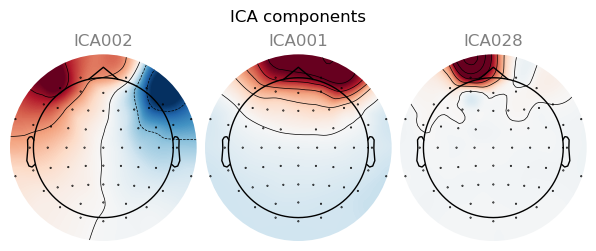

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
3697 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
3697 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
3697 matching events found
No baseline correction applied
0 projection items activated


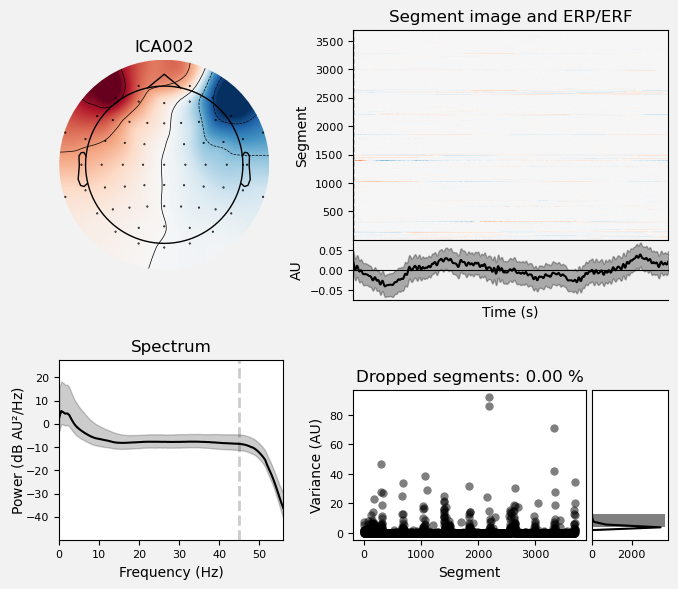

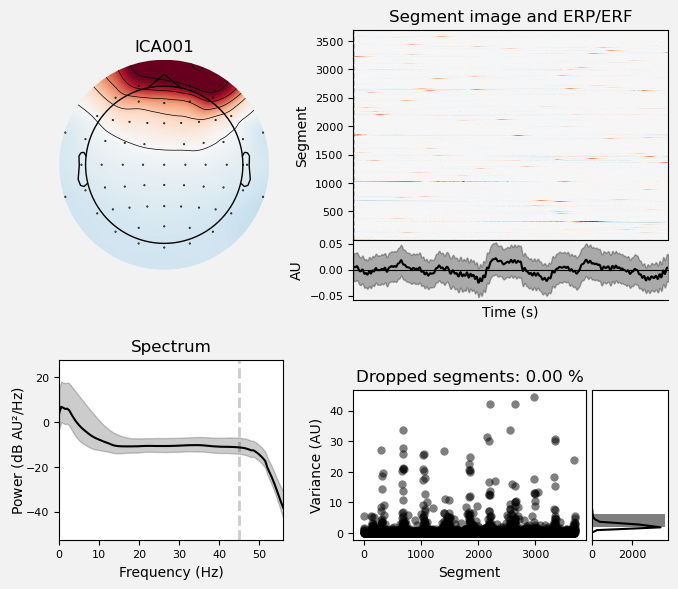

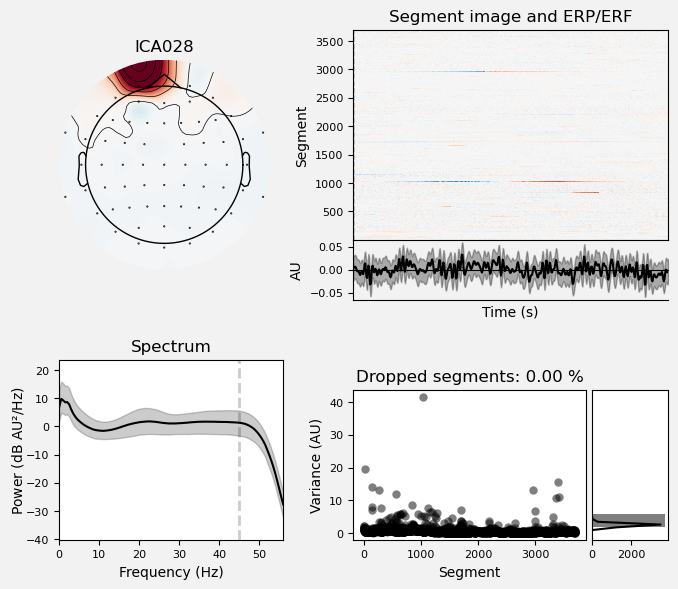

[<Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>]

In [39]:
# --- sanity-check visually (highly recommended) ---
ica.plot_components(eog_inds)     # confirm they look like frontal dipoles
ica.plot_properties(raw, picks=eog_inds)


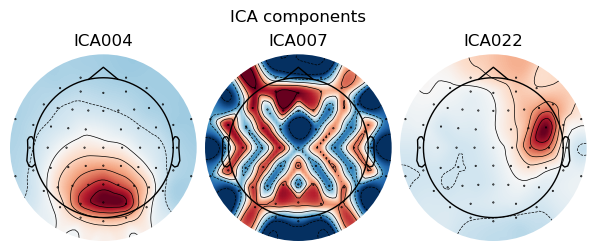

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
3697 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
3697 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
3697 matching events found
No baseline correction applied
0 projection items activated


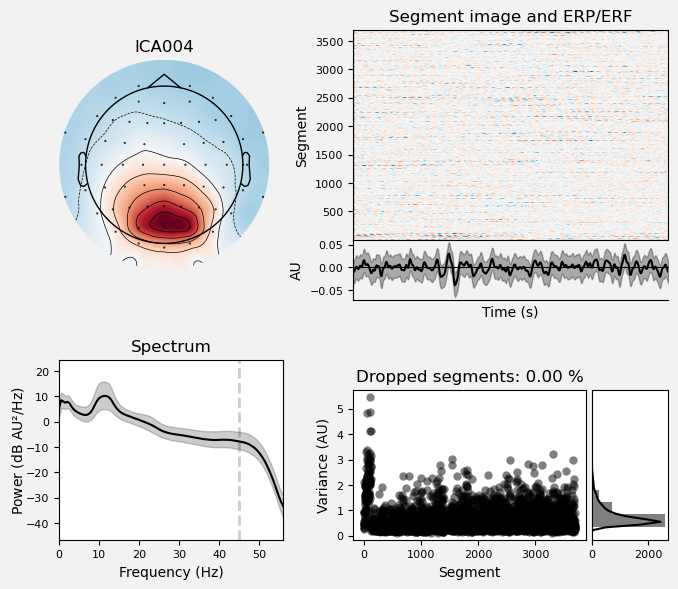

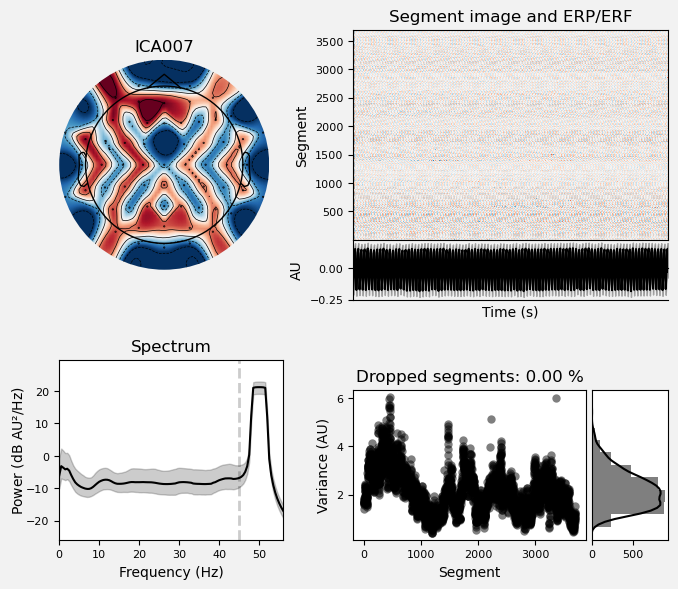

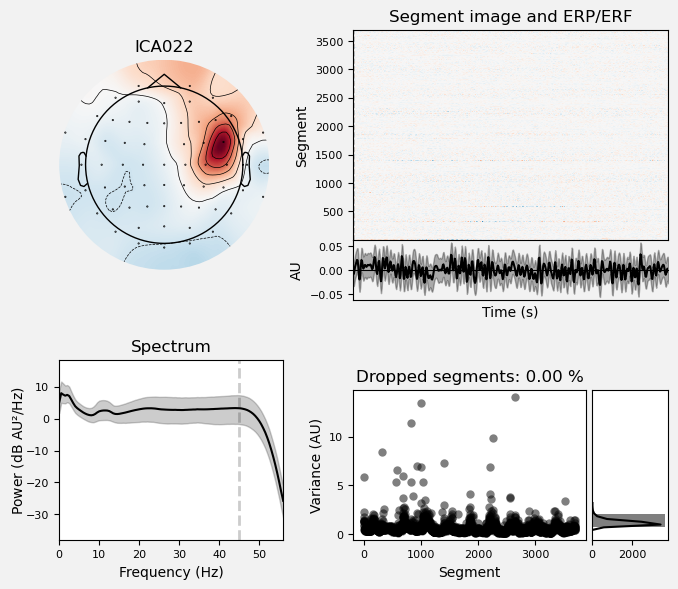

[<Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>]

In [41]:
good_inds = [4, 7, 22]
ica.plot_components(good_inds)     # confirm they look like frontal dipoles
ica.plot_properties(raw, picks=good_inds)

If a marked IC is not a blink, remove it from ica.exclude.
Conversely, if you spot an obvious blink component that wasn’t flagged, append its
index manually:
ica.exclude += [idx_to_add]

In [42]:

TOPOMAPS   = ica.get_components()           # shape (n_channels, n_components)
ch_names   = np.array(raw.ch_names)         # for a readable print-out

for k in range(TOPOMAPS.shape[1]):          # loop over components
    topo = np.abs(TOPOMAPS[:, k])
    # how many sensors carry ≥20 % of the max weight?
    n_big = np.sum(topo > 0.2 * topo.max())

    if n_big == 1:                          # only ONE channel dominates
        max_idx   = np.argmax(topo)         # sensor index
        max_ch    = ch_names[max_idx]       # sensor name
        max_w     = topo[max_idx]           # absolute weight
        energy_pc = (max_w**2 / np.sum(topo**2)) * 100

        # ── print a short diagnostic line ───────────────────────────────
        print(f"IC {k:02d}: {max_ch:>4s} carries {energy_pc:5.1f}% "
              f"of weight (|w|={max_w:.2e}) → marking as 1-channel noise")

        ica.exclude.append(k)               # mark for removal

IC 00:  FC1 carries  98.4% of weight (|w|=4.78e+00) → marking as 1-channel noise
IC 17:   T7 carries  89.1% of weight (|w|=9.19e-01) → marking as 1-channel noise
IC 18:  AF4 carries  90.4% of weight (|w|=9.41e-01) → marking as 1-channel noise
IC 28:  Fp1 carries  95.6% of weight (|w|=6.60e-01) → marking as 1-channel noise
IC 32:  AF7 carries  73.5% of weight (|w|=4.07e-01) → marking as 1-channel noise
IC 33:  CPz carries  92.9% of weight (|w|=3.71e-01) → marking as 1-channel noise


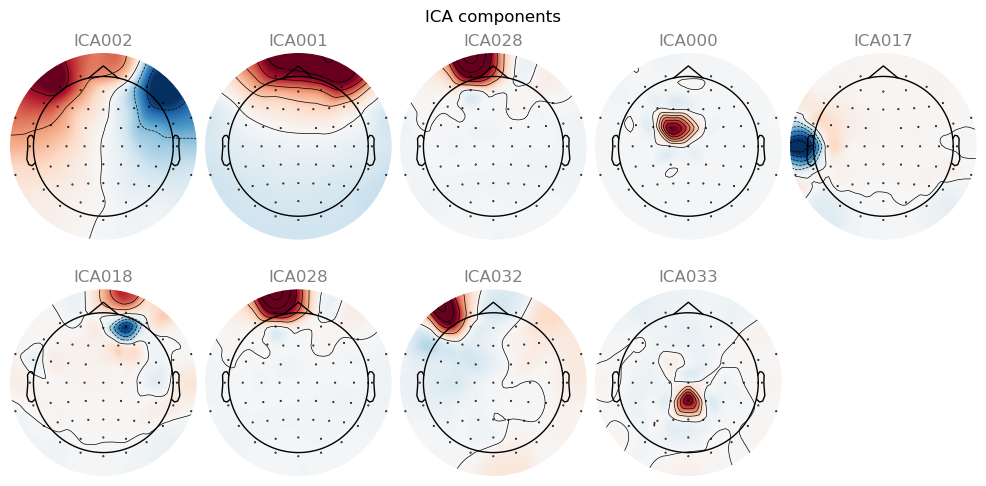

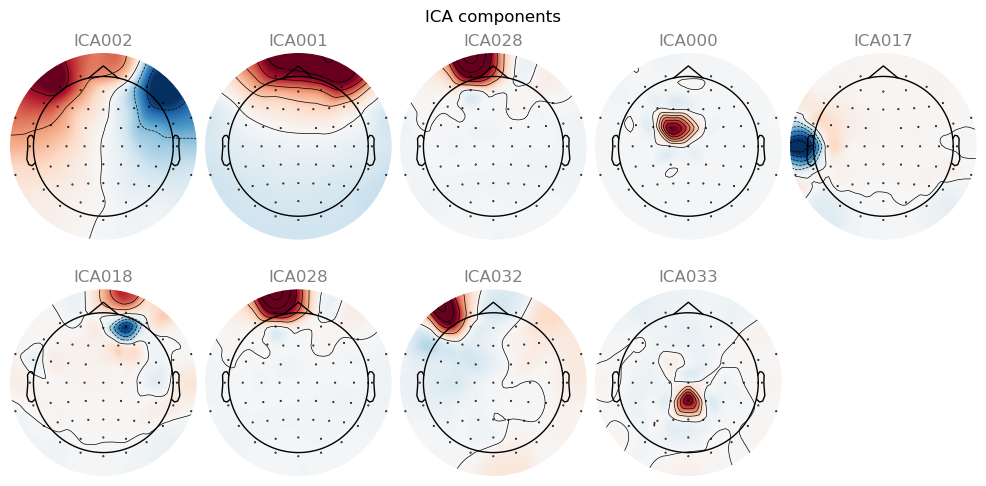

In [43]:
# optional: confirm those too
ica.plot_components(picks=ica.exclude)

In [44]:
raw_clean = ica.apply(raw.copy())           # subtracts the flagged ICs


Applying ICA to Raw instance
    Transforming to ICA space (34 components)
    Zeroing out 8 ICA components
    Projecting back using 63 PCA components


In [52]:
raw_path_out = os.path.join(OUT_DIR, f"sub-{subj:03d}_task-memory_eeg_amica.fif")
raw_clean.save(raw_path_out, overwrite=True)

Writing C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\EEG_amica_processed\sub-032_task-memory_eeg_amica.fif


C:\Users\cdd\AppData\Local\Temp\ipykernel_31872\1871077879.py:2: RuntimeWarning: This filename (C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\EEG_amica_processed\sub-032_task-memory_eeg_amica.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_clean.save(raw_path_out, overwrite=True)


Closing C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\EEG_amica_processed\sub-032_task-memory_eeg_amica.fif
[done]


In [56]:
import os, numpy as np, mne, matplotlib.pyplot as plt
from scipy.stats import sem

# ------------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------------
SUBJECTS   = [32]                            # ← or the list you want to loop over
ROI        = ['Fz']                          # pick any ROI you like
RESAMPLE   = 250                             # << already done, keep only if you want a *different* fs

# ------------------------------------------------------------------
# CONSTANTS (unchanged)
# ------------------------------------------------------------------
FREQS      = np.arange(1, 46)
N_CYCLES   = np.logspace(np.log10(3), np.log10(12), len(FREQS))
BASELINE   = (-2., -1.)                      # –2…–1 s as in the paper
BIN_DUR    = 2.0
LISTLEN_MAP = {5: 11., 9: 17., 13: 27.}
X_POS      = np.arange(1, 14)

# ------------------------------------------------------------------
# HELPERS  (unchanged)
# ------------------------------------------------------------------
def _theta_power(tfr, beg, end):
    f_sel = np.where((FREQS >= 4) & (FREQS <= 8))[0]
    return tfr.copy().crop(beg, end).data[:, f_sel, :].mean()

def _get_first_digit_ids(ids, cond_prefix, list_len):
    list_code = f"{list_len:02d}"
    return {code: eid for code, eid in ids.items()
            if code.startswith(cond_prefix) and code[2:4] == '01' and code[4:6] == list_code}

# ------------------------------------------------------------------
# MAIN LOOP
# ------------------------------------------------------------------
mem_all, ctrl_all = [], []

for subj in SUBJECTS:
    fif_path = os.path.join(OUT_DIR,
                            f"sub-{subj:03d}_task-memory_eeg_amica.fif")
    if not os.path.exists(fif_path):
        print(f"missing: {fif_path}")
        continue

    print(f"▶  Subject {subj:03d}")
    # 1) load the already-clean data  --------
    raw_ica = mne.io.read_raw_fif(fif_path, preload=True, verbose='error')

    # (optional) resample again only if you need a *new* rate
    # raw.resample(RESAMPLE, verbose='error')

    # 2) events & annotations ----------
    events, ids = mne.events_from_annotations(raw)

    mem_by_pos  = [[] for _ in range(13)]
    ctrl_by_pos = [[] for _ in range(13)]

    for n_digits, tmax in LISTLEN_MAP.items():
        for cond_prefix, bucket in [('60', mem_by_pos), ('50', ctrl_by_pos)]:
            first_ids = _get_first_digit_ids(ids, cond_prefix, n_digits)
            if not first_ids:
                continue
            ep = mne.Epochs(raw, events, event_id=first_ids,
                            tmin=-2., tmax=tmax, baseline=None,
                            picks='eeg', preload=True, verbose='error')

            # (optional) current-source density *after* epoching
            ep_csd = mne.preprocessing.compute_current_source_density(
                ep, # Copy the epochs to avoid modifying the original data
                sphere='auto',
                lambda2 = 1e-5,
                stiffness=4,
                n_legendre_terms=50,
                copy=True,
                verbose=True
            )

            tfr = mne.time_frequency.tfr_morlet(
                    ep_csd.pick_channels(ROI),
                    freqs=FREQS, n_cycles=N_CYCLES,
                    return_itc=False, verbose='error')

            tfr.apply_baseline(BASELINE, mode='percent')

            for pos in range(1, n_digits + 1):
                beg, end = BIN_DUR*(pos-1), BIN_DUR*pos
                bucket[pos-1].append(_theta_power(tfr, beg, end))

    mem_all.append([np.nanmean(v) if v else np.nan for v in mem_by_pos])
    ctrl_all.append([np.nanmean(v) if v else np.nan for v in ctrl_by_pos])


▶  Subject 032
Used Annotations descriptions: ['500105', '500109', '500113', '500205', '500209', '500213', '500305', '500309', '500313', '500405', '500409', '500413', '500505', '500509', '500513', '500609', '500613', '500709', '500713', '500809', '500813', '500909', '500913', '501013', '501113', '501213', '501313', '6001051', '6001090', '6001091', '6001130', '6001131', '6002051', '6002090', '6002091', '6002130', '6002131', '6003051', '6003090', '6003091', '6003130', '6003131', '6004051', '6004090', '6004091', '6004130', '6004131', '6005051', '6005090', '6005091', '6005130', '6005131', '6006090', '6006091', '6006130', '6006131', '6007090', '6007091', '6007130', '6007131', '6008090', '6008091', '6008130', '6008131', '6009090', '6009091', '6009130', '6009131', '6010130', '6011130', '6012130', '6013130', 'boundary']
Fitted sphere radius:         100.0 mm
Origin head coordinates:      -0.0 -0.0 0.0 mm
Origin device coordinates:    -0.0 -0.0 0.0 mm
NOTE: pick_channels() is a legacy function.

C:\Users\cdd\AppData\Local\Temp\ipykernel_31872\216609012.py:26: RuntimeWarning: tmax is not in time interval. tmax is set to <class 'mne.time_frequency.tfr.AverageTFR'>.tmax (17 s)
  return tfr.copy().crop(beg, end).data[:, f_sel, :].mean()


Fitted sphere radius:         100.0 mm
Origin head coordinates:      -0.0 -0.0 0.0 mm
Origin device coordinates:    -0.0 -0.0 0.0 mm
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: percent)


C:\Users\cdd\AppData\Local\Temp\ipykernel_31872\216609012.py:26: RuntimeWarning: tmax is not in time interval. tmax is set to <class 'mne.time_frequency.tfr.AverageTFR'>.tmax (17 s)
  return tfr.copy().crop(beg, end).data[:, f_sel, :].mean()


Fitted sphere radius:         100.0 mm
Origin head coordinates:      -0.0 -0.0 0.0 mm
Origin device coordinates:    -0.0 -0.0 0.0 mm
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: percent)
Fitted sphere radius:         100.0 mm
Origin head coordinates:      -0.0 -0.0 0.0 mm
Origin device coordinates:    -0.0 -0.0 0.0 mm
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: percent)


c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\numpy\core\_methods.py:195: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


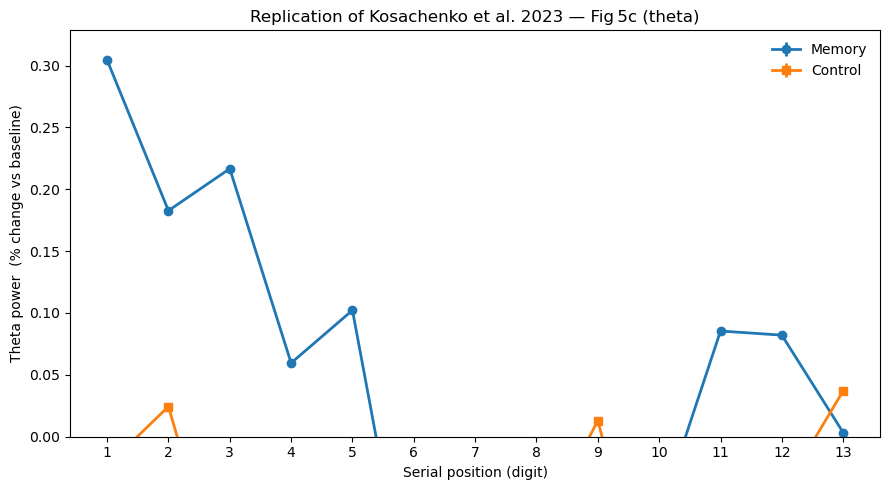

In [58]:
mem_all  = np.asarray(mem_all,  float)
ctrl_all = np.asarray(ctrl_all, float)

plt.figure(figsize=(9, 5))
plt.errorbar(X_POS, np.nanmean(mem_all,  axis=0),
             yerr=sem(mem_all,  axis=0, nan_policy='omit'),
             marker='o', label='Memory', linewidth=2)
plt.errorbar(X_POS, np.nanmean(ctrl_all, axis=0),
             yerr=sem(ctrl_all, axis=0, nan_policy='omit'),
             marker='s', label='Control', linewidth=2)
plt.xlabel('Serial position (digit)')
plt.ylabel('Theta power  (% change vs baseline)')
plt.title('Replication of Kosachenko et al. 2023 — Fig 5c (theta)')
plt.xticks(X_POS)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'theta_replication.png'), dpi=300)
plt.show()

In [60]:
import pathlib
from matplotlib.ticker import PercentFormatter

PLOT_INDIVIDUAL = True          # set False to skip the plots

SUBJ_DIR         = pathlib.Path(os.path.join(OUT_DIR, 'sub-plots'))
SUBJ_DIR.mkdir(exist_ok=True)

suspects = []                   # will collect subject IDs > 40 %

for subj_idx, subj in enumerate(SUBJECTS):
    mem_curve  = mem_all[subj_idx]
    ctrl_curve = ctrl_all[subj_idx]

    if np.nanmax(np.abs(mem_curve)) > 0.40:   # 40 % threshold
        suspects.append(subj)

    if not PLOT_INDIVIDUAL:
        continue

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(X_POS, mem_curve,  '-o', label='Memory',  alpha=.8)
    ax.plot(X_POS, ctrl_curve, '-s', label='Control', alpha=.8)
    ax.set(title = f'Subject {subj:03d}',
           xlabel = 'Serial position (digit)',
           ylabel = 'Theta power (% vs baseline)')
    ax.xaxis.set_ticks(X_POS)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))  # 0.10 → 10 %
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(SUBJ_DIR / f'sub-{subj:03d}_theta.png')
    plt.close(fig)
